In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

In [20]:
if_mean = pd.read_csv("IF_600_new_MeanAgeImput_Rounded_pclasswithsex_new.csv")
if_median = pd.read_csv("IF_600_new_MedianAgeImput_pclasswithsex.csv")

tc_mean = pd.read_csv("TC_600_new_MeanAgeImput_Rounded_pclasswithsex_new.csv")
tc_median = pd.read_csv("TC_600_new_MedianAgeImput_pclasswithsex.csv")

data_mean = pd.read_csv("IF_600_new_MeanAgeImput_Rounded_pclasswithsex_OriginalData_new.csv")
data_median = pd.read_csv("IF_600_new_MedianAgeImput_pclasswithsex_OriginalData.csv")

In [21]:
def prepare_rank_displacement(
    mean_df,
    median_df,
    age_df,
    method_name
):
    """
    Compare influence rankings under mean and median age imputation.

    Normalised rank displacement:
        |rank_mean - rank_median| / (N - 1)
    """

    # Match the same training samples by Train_ID
    merged_method = (
        mean_df[["Train_ID", "Score"]]
        .rename(columns={"Score": "Score_mean"})
        .merge(
            median_df[["Train_ID", "Score"]].rename(
                columns={"Score": "Score_median"}
            ),
            on="Train_ID",
            how="inner",
            validate="one_to_one"
        )
    )

    # Rank 1 means the largest signed influence score
    merged_method["Rank_mean"] = merged_method["Score_mean"].rank(
        ascending=False,
        method="average"
    )

    merged_method["Rank_median"] = merged_method["Score_median"].rank(
        ascending=False,
        method="average"
    )

    # Absolute rank movement
    merged_method["Delta_rank"] = (
        merged_method["Rank_mean"]
        - merged_method["Rank_median"]
    ).abs()

    # Normalise by the largest possible displacement
    n = len(merged_method)

    # merged_method["Delta_rank_norm"] = (
    #     merged_method["Delta_rank"] / (n - 1)
    # )
    merged_method["Delta_rank_norm"] = (
        merged_method["Delta_rank"] / (n - 1)
    )

    # Obtain the original imputation indicator
    age_info = age_df[
        ["id", "feature_8"]
    ].rename(columns={
        "id": "Train_ID",
        "feature_8": "Age_imputed"
    })

    merged_method = merged_method.merge(
        age_info,
        on="Train_ID",
        how="left",
        validate="one_to_one"
    )

    merged_method["Imputation_status"] = (
        merged_method["Age_imputed"].map({
            0: "Non-imputed",
            1: "Imputed"
        })
    )

    merged_method["Method"] = method_name

    return merged_method

In [22]:
foif_rank_df = prepare_rank_displacement(
    mean_df=if_mean,
    median_df=if_median,
    age_df=data_mean,
    method_name="FOIF"
)

tracin_rank_df = prepare_rank_displacement(
    mean_df=tc_mean,
    median_df=tc_median,
    age_df=data_mean,
    method_name="TracIn"
)

In [23]:
print(foif_rank_df.head())
print(tracin_rank_df.head())

print(foif_rank_df["Imputation_status"].value_counts())
print(tracin_rank_df["Imputation_status"].value_counts())

   Train_ID  Score_mean  Score_median  Rank_mean  Rank_median  Delta_rank  \
0       483    1.642138      0.501978        1.0          2.0         1.0   
1       258    1.209735      0.092993        2.0        301.0       299.0   
2        16    0.846183      0.197196        3.0        190.0       187.0   
3       477    0.563332      0.362820        4.0         21.0        17.0   
4       371    0.538838      0.411293        5.0          8.0         3.0   

   Delta_rank_norm  Age_imputed Imputation_status Method  
0         0.001669          0.0       Non-imputed   FOIF  
1         0.499165          0.0       Non-imputed   FOIF  
2         0.312187          0.0       Non-imputed   FOIF  
3         0.028381          0.0       Non-imputed   FOIF  
4         0.005008          0.0       Non-imputed   FOIF  
   Train_ID  Score_mean  Score_median  Rank_mean  Rank_median  Delta_rank  \
0        96    0.156271      0.161178        1.0          5.0         4.0   
1       493    0.148108      

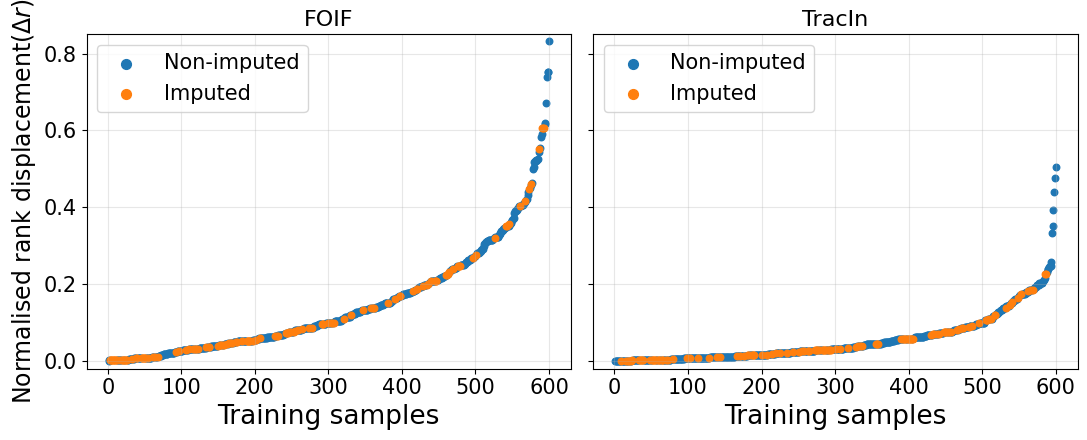

In [35]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4.5),
    sharey=True
)

plot_data = [
    ("FOIF", foif_rank_df, axes[0]),
    ("TracIn", tracin_rank_df, axes[1])
]

colors = {
    "Non-imputed": "#1f77b4",
    "Imputed": "#ff7f0e"
}

for method, df_plot, ax in plot_data:

    # Sort ALL samples together
    df_plot = (
        df_plot
        .sort_values("Delta_rank_norm")
        .reset_index(drop=True)
    )

    x = np.arange(1, len(df_plot) + 1)

    for status in ["Non-imputed", "Imputed"]:

        subset = df_plot[
            df_plot["Imputation_status"] == status
        ]

        ax.scatter(
            subset.index + 1,
            subset["Delta_rank_norm"],
            s=22,
            color=colors[status],
            label=status
        )

    ax.set_title(method, fontsize=16)

    ax.set_xlabel(
        "Training samples",
        fontsize=19
    )

    ax.tick_params(
        axis='both',
        labelsize=15
    )

    ax.legend(
        fontsize=15,
        loc="upper left",
        markerscale=1.5
    )

    ax.grid(alpha=0.3)

axes[0].set_ylabel(
    r"Normalised rank displacement($\Delta r$)",
    fontsize=17
)

axes[0].set_ylim(-0.02, 0.85)

axes[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8])

plt.tight_layout()

plt.savefig(
    "Titanic_RankDisplacement_Dots.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Titanic_RankDisplacement_Dots.pdf",
    bbox_inches="tight"
)

plt.show()